# Evaluation – Netflix Model

In this notebook the trained model is evaluated. The goal is to check which fields are important, calculate suitable metrics and create a confusion matrix.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

In [2]:
df = pd.read_csv("netflix_titles_clean.csv", sep=";")

df = df.dropna(subset=["type", "release_year", "rating", "duration"])

df["duration_number"] = df["duration"].str.extract(r"(\d+)").astype(float)

df.head()

,type,title,country,release_year,rating,duration,listed_in,duration_number
0,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries,90.0
1,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2.0
2,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0
3,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV",1.0
4,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2.0


In [3]:
features = ["release_year", "duration_number"]
target = "type"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 4.1 Important Fields

The most important fields for this model are **duration_number** and **release_year**. The field duration_number is especially useful because movies usually have a duration in minutes, while TV shows often have seasons. The release year can also provide useful information because the distribution of Movies and TV Shows changes over time. These two fields are therefore meaningful for predicting the type of a Netflix title.

In [4]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9958333333333333


## 4.2 Metric

Accuracy was selected as a suitable metric because this is a classification problem with two possible target values: Movie and TV Show. Accuracy shows how many predictions were correct compared to all predictions. This gives a clear first impression of how well the model performs on the test dataset.

In [5]:
labels = ["Movie", "TV Show"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[163   0]
 [  1  76]]


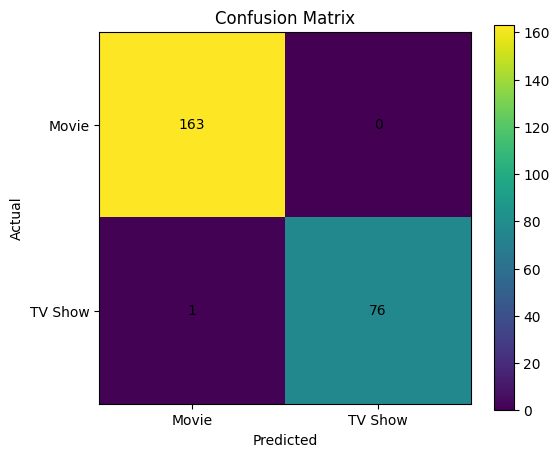

In [6]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [7]:
precision = precision_score(y_test, y_pred, pos_label="Movie")
recall = recall_score(y_test, y_pred, pos_label="Movie")

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9939024390243902
Recall: 1.0


## 4.3 Confusion Matrix, Precision and Recall

The confusion matrix shows how many Movies and TV Shows were classified correctly or incorrectly. Precision shows how many titles predicted as Movies were actually Movies. Recall shows how many real Movies were correctly detected by the model. These values are useful because they give more detailed information than accuracy alone.

## 4.4 Model Evaluation Summary

The model works very well for a simple first classification. The high accuracy shows that the selected fields are useful for predicting whether a title is a Movie or a TV Show. Duration is probably the strongest field because Movies and TV Shows have different formats. However, the model could still make mistakes when titles have similar durations or unusual formats.